# Image classification with EfficientNetV2s

In [ ]:
from google.colab import drive
drive.mount('/content/Mydrive')

# Install libraries and Download dataset


In [ ]:
!pip install lightning wandb -qU

In [ ]:
import torchvision
from torchvision import transforms, models
from torchmetrics import Accuracy

from lightning.pytorch import LightningModule, Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, classification_report
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import wandb
from PIL import Image
import kagglehub
import seaborn as sns
import time
import pandas as pd
import math
import random
import os
import numpy as np


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed_everything(42, workers=True)

In [ ]:
dataset_path = kagglehub.dataset_download("ma7555/cat-breeds-dataset")
dataset = torchvision.datasets.ImageFolder(root=os.path.join(dataset_path, 'images'))

In [ ]:
dataset.classes

# Helper Fucntion

In [ ]:
def evaluation(model, test_loader):
  model.eval()
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for data in tqdm(test_loader):
       image, label = data
       image = image.to(device)
       label = label.to(device)

       pred = model(image)
       pred = pred.argmax(dim=1)

       all_preds.append(pred.cpu().numpy())
       all_labels.append(label.cpu().numpy())

  y_pred = np.concatenate(all_preds)
  y_true = np.concatenate(all_labels)
  return y_pred, y_true

def display_heatmap(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(12,10))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=selected_breeds, yticklabels=selected_breeds)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()


def get_embeddings(model, dataset, transform, batch_size=32):
  all_embeddings = []
  all_labels = []
  model.eval()

  test_dataset = TSNEDataset(dataset, transform, class_map)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  with torch.no_grad():
    for img, label, in tqdm(test_loader):
        img = img.to(device)

        _, features,_ = model.extract_feature(img)

        all_embeddings.append(features.cpu())
        all_labels.extend(label)
  embeddings = torch.cat(all_embeddings, dim=0)
  labels = np.array(all_labels)
  return embeddings, labels

def get_tsne(model):
  embeddings, labels = get_embeddings(model, test_set, val_transform, batch_size=32)
  tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', verbose=1)
  tsne_result = tsne.fit_transform(embeddings)
  return embeddings, labels, tsne_result

def display_tsne(tsne, labels, title):
  df = pd.DataFrame({
    'tsne-1': tsne[:, 0],
    'tsne-2': tsne[:, 1],
    'breed': [selected_breeds[i] for i in labels]
  })

  plt.figure(figsize=(12, 8))
  sns.scatterplot(
      x="tsne-1", y="tsne-2",
      hue="breed",
      palette=sns.color_palette("hls", len(selected_breeds)),
      data=df,
      legend="full",
      alpha=0.7
  )

  plt.title(title)
  plt.legend()
  plt.show()

class TSNEDataset(Dataset):
  def __init__(self, dataset, transform=None, class_map=None):
    self.dataset = dataset
    self.transform = transform
    self.class_map = class_map

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    img, label = self.dataset[idx]
    img = img.convert('RGB')
    if self.transform is not None:
        img = self.transform(img)

    if self.class_map is not None:
        label = self.class_map[label]

    return img, label

# Wandb

In [ ]:
os.environ["WANDB_API_KEY"] = "YOUR_WANDB_API_KEY"
wandb.login()

# Preparing Data

## Spliting the dataset

In [ ]:
train_subsets = []
val_subsets = []
test_subsets = []
selected_breeds = []

for breed in dataset.classes:
    breed_path = os.path.join(dataset_path, 'images', breed)
    num_images = len(os.listdir(breed_path))

    if not (3000 <= num_images <= 6000):
        continue

    selected_breeds.append(breed)
    breed_idx = dataset.class_to_idx[breed]
    indices = [i for i, (_, label_idx) in enumerate(dataset.imgs) if label_idx == breed_idx]
    indices = np.random.permutation(indices)
    selected_indices = indices[:1000]

    n = len(selected_indices)
    train_end = int(0.8 * n)
    val_end = int(0.90 * n)

    train_subsets.append(Subset(dataset, selected_indices[:train_end]))
    val_subsets.append(Subset(dataset, selected_indices[train_end:val_end]))
    test_subsets.append(Subset(dataset, selected_indices[val_end:]))

    test_subsets.append(Subset(dataset, indices[1000:1200]))

train_set = ConcatDataset(train_subsets)
val_set = ConcatDataset(val_subsets)
test_set = ConcatDataset(test_subsets)

In [ ]:
selected_breeds

In [ ]:
len(train_set), len(val_set), len(test_set)

Show some image in train_set

In [ ]:
idx_to_class = {idx: class_name for class_name, idx in dataset.class_to_idx.items()}
indices = np.random.choice(len(train_set), 5, replace=False)
plt.figure(figsize=(10, 5))
for i, idx in enumerate(indices):
   image, label_idx = train_set[idx]
   plt.subplot(1, 5, i + 1)
   plt.imshow(image)
   plt.title(idx_to_class[label_idx])
   plt.axis('off')
plt.tight_layout()
plt.show()

## Normalize the dataset

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # imagenet
 ])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
class_map = {old_idx: new_idx for new_idx, old_idx in enumerate([dataset.class_to_idx[b] for b in selected_breeds])}

In [ ]:
class_map

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, data, transforms=None, class_map=None):
      self.transforms = transforms
      self.data = data
      self.class_map = class_map

  def __len__(self):
      return len(self.data)

  def __getitem__(self, idx):
      x, y = self.data[idx]

      if self.class_map:
            y = self.class_map[y]

      if self.transforms:
          x = self.transforms(x)
      return x, y

train_dataset = CustomDataset(train_set, train_transform, class_map)
val_dataset = CustomDataset(val_set, val_transform, class_map)
test_dataset = CustomDataset(test_set, val_transform, class_map)

In [ ]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# CrossEntropy

In [ ]:
class EfficientNetV2(LightningModule):
    def __init__(self, num_classes=11, learning_rate=2e-5,num_epochs=10):
        super().__init__()
        self.model = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
        self.model.classifier[1] = nn.Sequential(
            nn.Linear(self.model.classifier[1].in_features,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

        self.loss_fn = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.save_hyperparameters()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.accuracy(logits, y)

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.accuracy(logits, y)

        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=0.01)

        scheduler = torch.optim.lr_scheduler.LinearLR(
          optimizer,
          start_factor=1.0,
          end_factor=0.1,
          total_iters= self.num_epochs
        )

        return {
          "optimizer": optimizer,
          "lr_scheduler": {
             "scheduler": scheduler,
             "interval": "epoch"
          }
        }

## Training

In [ ]:
total_epochs = 30
base_model = EfficientNetV2(num_epochs=total_epochs)
wandb_logger = WandbLogger(project="Image_classification_EfficientNetV2",  name="base model")

checkpoint_callback = ModelCheckpoint(
    dirpath="/content/Mydrive/MyDrive/base_model_checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="base-{epoch:02d}-{val_acc:.2f}-{val_loss:.4f}",
    verbose=True,
)

trainer = Trainer(
    max_epochs=total_epochs,
    callbacks=[checkpoint_callback],
    logger=wandb_logger
)
trainer.fit(base_model, train_loader, val_loader)
wandb.finish()

## Evaluation

In [ ]:
base_model = EfficientNetV2.load_from_checkpoint(checkpoint_callback.best_model_path).to(device)

In [ ]:
base_y_pred,  base_y_true =  evaluation(base_model, test_loader)

In [ ]:
report = classification_report(
    base_y_true,
    base_y_pred,
    target_names=selected_breeds,
    digits=4
)
print(report)

## Heatmap

In [ ]:
display_heatmap(base_y_true, base_y_pred)

# Triplet & CE Loss

## Triplet Dataset

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, full_dataset, dataset, class_map=None, transform=None):
        self.full_dataset = full_dataset
        self.dataset = dataset
        self.transform = transform
        self.label_to_indices = {}
        self.class_map = class_map
        self.load_image()

    def load_image(self):
        self.label_to_indices = {old_idx: [] for old_idx in self.class_map.keys()}
        for idx, (_, label) in enumerate(self.full_dataset.imgs):
            if label in self.class_map:
              self.label_to_indices[label].append(idx)

    def __getitem__(self, index):
        anchor_img, anchor_label = self.dataset[index]

        pos_idx = index
        while pos_idx == index:
            pos_idx = random.choice(self.label_to_indices[anchor_label])
        pos_img, pos_label = self.full_dataset[pos_idx]

        neg_label = anchor_label
        while neg_label == anchor_label :
            neg_label = random.choice(list(self.class_map.keys()))

        neg_index = random.choice(self.label_to_indices[neg_label])
        neg_img, neg_label = self.full_dataset[neg_index]

        anchor_label = self.class_map[anchor_label]
        pos_label = self.class_map[pos_label]
        neg_label = self.class_map[neg_label]

        if self.transform:
          anchor_img = self.transform(anchor_img)
          pos_img = self.transform(pos_img)
          neg_img = self.transform(neg_img)

        return anchor_img, pos_img, neg_img, anchor_label, pos_label, neg_label

    def __len__(self):
        return len(self.dataset)

triplet_train_dataset = TripletDataset(dataset, train_set, class_map, train_transform)
triplet_val_dataset = TripletDataset(dataset, val_set, class_map, val_transform)
triplet_test_dataset = test_dataset

batch_size = 16
triplet_train_loader = DataLoader(triplet_train_dataset, batch_size=batch_size, shuffle=True)
triplet_val_loader = DataLoader(triplet_val_dataset, batch_size=batch_size, shuffle=False)
triplet_test_loader = DataLoader(triplet_test_dataset, batch_size=batch_size, shuffle=False)

## Define Network

In [ ]:
def weights_init_kaiming(m):
    if isinstance(m, nn.BatchNorm1d):
        if m.weight is not None:
            nn.init.constant_(m.weight, 1.0)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

def weights_init_classifier(m):
    if isinstance(m, nn.Linear):
        if m.weight is not None:
           nn.init.normal_(m.weight, std=0.001)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

class TripletNetwork(LightningModule):
    def __init__(self, num_classes=11, learning_rate=1e-4, num_epochs=10):
        super().__init__()
        self.model = models.efficientnet_v2_s(weights="IMAGENET1K_V1")

        self.conv = torch.nn.Sequential(*(list(self.model.children())[:-1]))
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.bottleneck = nn.BatchNorm1d(1280)
        self.bottleneck.bias.requires_grad_(False)
        self.bottleneck.apply(weights_init_kaiming)

        self.classifier = nn.Linear(1280, num_classes, bias=False)
        self.classifier.apply(weights_init_classifier)

        self.triplet_loss_fn = nn.TripletMarginLoss(margin=0.3, p=2)
        self.crossentropy_loss_fn = nn.CrossEntropyLoss()

        self.learning_rate = learning_rate
        self.save_hyperparameters()
        self.num_epochs = num_epochs


    def extract_feature(self, x):
        x = self.conv(x)
        x = self.global_pool(x)
        global_feat = torch.flatten(x, 1)
        feat = self.bottleneck(global_feat)
        return feat, global_feat, self.classifier(feat)

    def forward(self, x):
        _, _, logits  = self.extract_feature(x)
        return logits

    def training_step(self, batch, batch_idx):
        anc_img, pos_img, neg_img, anc_label, pos_label, neg_label = batch

        all_imgs = torch.cat([anc_img, pos_img, neg_img], dim=0)
        all_labels = torch.cat([anc_label, pos_label, neg_label], dim=0)
        _, all_global_feat, all_scores = self.extract_feature(all_imgs)

        n = anc_img.size(0)
        anc_g, pos_g, neg_g = all_global_feat[:n], all_global_feat[n:2*n], all_global_feat[2*n:]

        loss_ce = self.crossentropy_loss_fn(all_scores, all_labels)
        loss_tri = self.triplet_loss_fn(
            F.normalize(anc_g, p=2, dim=1),
            F.normalize(pos_g, p=2, dim=1),
            F.normalize(neg_g, p=2, dim=1)
        )
        train_loss = loss_tri + loss_ce

        self.log("train_loss", train_loss, on_epoch=True, prog_bar=True)
        return train_loss

    def validation_step(self, batch, batch_idx):
        anc_img, pos_img, neg_img, anc_label, pos_label, neg_label = batch

        all_imgs = torch.cat([anc_img, pos_img, neg_img], dim=0)
        all_labels = torch.cat([anc_label, pos_label, neg_label], dim=0)
        _, all_global_feat, all_scores = self.extract_feature(all_imgs)

        n = anc_img.size(0)
        anc_g, pos_g, neg_g = all_global_feat[:n], all_global_feat[n:2*n], all_global_feat[2*n:]

        loss_ce = self.crossentropy_loss_fn(all_scores, all_labels)
        loss_tri = self.triplet_loss_fn(
            F.normalize(anc_g, p=2, dim=1),
            F.normalize(pos_g, p=2, dim=1),
            F.normalize(neg_g, p=2, dim=1)
        )

        preds = torch.argmax(all_scores[:n], dim=1)
        acc = (preds == anc_label).float().mean()
        val_loss = loss_ce + loss_tri

        self.log("val_loss", val_loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        return val_loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=0.01)

        scheduler = torch.optim.lr_scheduler.LinearLR(
          optimizer,
          start_factor=1.0,
          end_factor=0.1,
          total_iters=self.num_epochs
        )

        return {
          "optimizer": optimizer,
          "lr_scheduler": {
             "scheduler": scheduler,
             "interval": "epoch"
          }
        }


## Training

In [ ]:
total_epochs = 30
triplet_model = TripletNetwork(num_epochs=total_epochs)
wandb_logger = WandbLogger(project="Image_classification_EfficientNetV2",  name="triplet & ce")

triplet_checkpoint = ModelCheckpoint(
    dirpath="/content/Mydrive/MyDrive/triplet_model_checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="tri-{epoch:02d}-{val_acc:.2f}-{val_loss:.4f}",
    verbose=True,
)

trainer = Trainer(max_epochs=total_epochs, callbacks=[triplet_checkpoint], logger=wandb_logger)
trainer.fit(triplet_model, triplet_train_loader, triplet_val_loader)
wandb.finish()

## Evaluation

In [ ]:
triplet_model = TripletNetwork.load_from_checkpoint(triplet_checkpoint.best_model_path).to(device)

In [ ]:
triplet_y_pred,  triplet_y_true =  evaluation(triplet_model, test_loader)

In [ ]:
report = classification_report(
    triplet_y_true,
    triplet_y_pred,
    target_names=selected_breeds,
    digits=4
)
print(report)

## Heatmap

In [ ]:
display_heatmap(triplet_y_true, triplet_y_pred)

## Plot T-SNE

In [ ]:
_, triplet_labels, triplet_tsne = get_tsne(triplet_model)

In [ ]:
display_tsne(triplet_tsne, triplet_labels, "Triplet & CE Loss")

# Hard Negative Mining

In [ ]:
class HardNegativeDataset(Dataset):
    def __init__(self, full_dataset, dataset, class_map=None, transform=None):
        self.full_dataset = full_dataset
        self.dataset = dataset
        self.transform = transform
        self.label_to_indices = {}
        self.class_map = class_map
        self.load_image()

        self.hard_prop = 0.7
        self.hard = {
            3: [24, 58, 65],
            21: [22],
            22: [21],
            23: [24],
            24: [23]
        }

    def load_image(self):
        self.label_to_indices = {old_idx: [] for old_idx in self.class_map.keys()}
        for idx, (_, label) in enumerate(self.full_dataset.imgs):
            if label in self.class_map:
              self.label_to_indices[label].append(idx)

    def __getitem__(self, index):
        anc_img, anc_label = self.dataset[index]

        pos_idx = random.choice(self.label_to_indices[anc_label])
        pos_img, pos_label = self.full_dataset[pos_idx]

        is_hard_class = anc_label in self.hard

        if is_hard_class and random.random() < self.hard_prop:
            neg_label = random.choice(self.hard[anc_label])
        else:
            neg_label = anc_label
            all_labels = list(self.class_map.keys())
            while neg_label == anc_label:
                neg_label = random.choice(all_labels)

        neg_index = random.choice(self.label_to_indices[neg_label])
        neg_img, neg_label = self.full_dataset[neg_index]

        anc_label = self.class_map[anc_label]
        pos_label = self.class_map[pos_label]
        neg_label = self.class_map[neg_label]

        if self.transform:
          anc_img = self.transform(anc_img)
          pos_img = self.transform(pos_img)
          neg_img = self.transform(neg_img)

        return anc_img, pos_img, neg_img, anc_label, pos_label, neg_label

    def __len__(self):
        return len(self.dataset)

hard_train_dataset = HardNegativeDataset(dataset, train_set, class_map, train_transform)
hard_val_dataset = HardNegativeDataset(dataset, val_set, class_map, val_transform)

batch_size = 16
hard_train_loader = DataLoader(hard_train_dataset, batch_size=batch_size, shuffle=True)
hard_val_loader = DataLoader(hard_val_dataset, batch_size=batch_size, shuffle=False)

## Training

In [ ]:
total_epochs = 30
hard_model = TripletNetwork(num_epochs=total_epochs)
wandb_logger = WandbLogger(project="Image_classification_EfficientNetV2",  name="hard negative mining")

hard_checkpoint = ModelCheckpoint(
    dirpath="/content/Mydrive/MyDrive/hard_model_checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="hard-{epoch:02d}-{val_acc:.2f}-{val_loss:.4f}",
    verbose=True,
)

trainer = Trainer(max_epochs=total_epochs, callbacks=[hard_checkpoint], logger=wandb_logger)
trainer.fit(hard_model, hard_train_loader, hard_val_loader)
wandb.finish()

## Evaluation

In [ ]:
hard_model = TripletNetwork.load_from_checkpoint(hard_checkpoint.best_model_path).to(device)

In [ ]:
hard_y_pred,  hard_y_true =  evaluation(hard_model, test_loader)

In [ ]:
report = classification_report(
    hard_y_true,
    hard_y_pred,
    target_names=selected_breeds,
    digits=4
)
print(report)

## Heatmap

In [ ]:
display_heatmap(hard_y_true, hard_y_pred)

## Plot T-SNE

In [ ]:
_, hard_labels, hard_tsne = get_tsne(hard_model)

In [ ]:
display_tsne(hard_tsne, hard_labels, "Hard Negative Mining")

# Loss & Accuracy

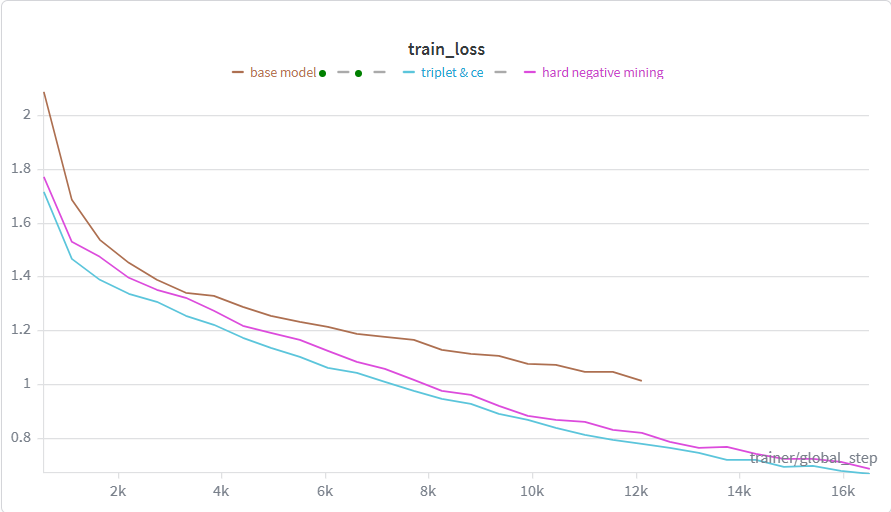

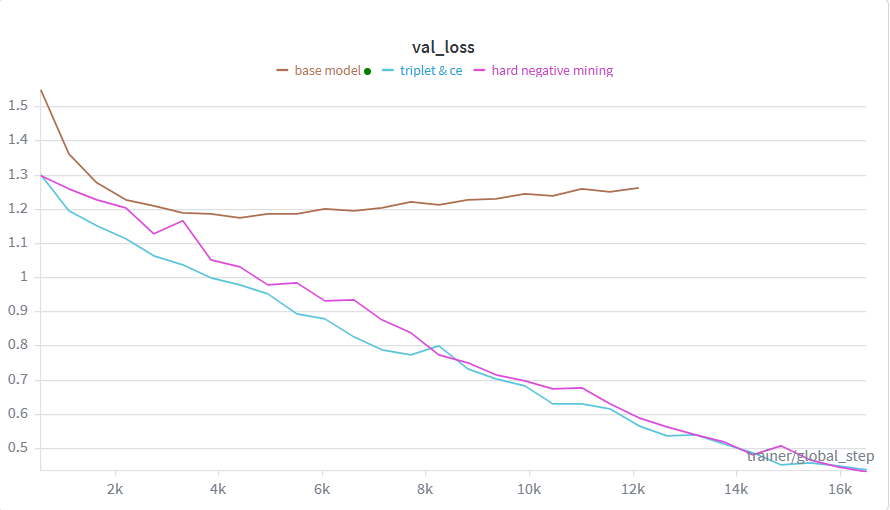

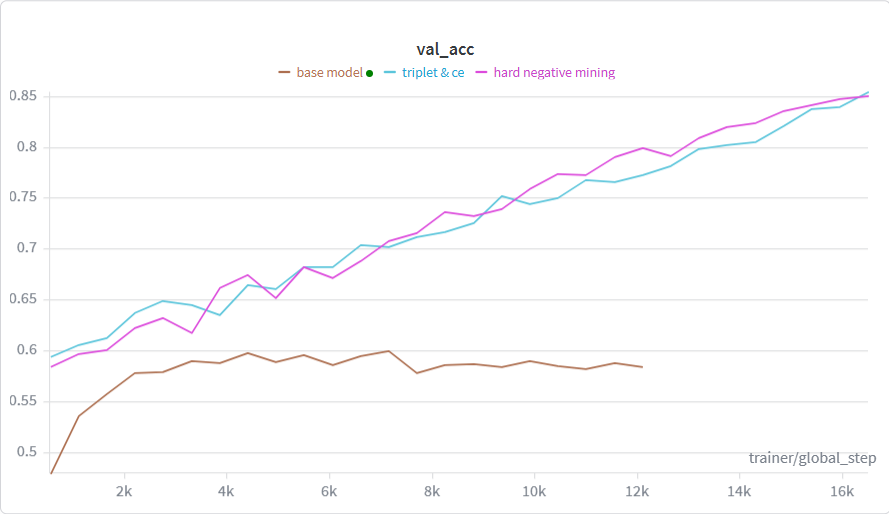

# Inference

In [ ]:
best_model = hard_model

In [ ]:
plt.figure(figsize=(20, 5))
dataiter = iter(test_loader)
inputs, labels = next(dataiter)

best_model.eval()
with torch.no_grad():
    inputs = inputs.to(device)
    outputs = best_model(inputs)

    y_probs = torch.nn.functional.softmax(outputs, dim=1)
    confidences, predictions = torch.max(y_probs, dim=1)

class_names = dataset.classes

for i in range(10):
    plt.subplot(2, 5, i+1)

    img = inputs[i].cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean

    npimg = img.numpy().clip(0, 1)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

    pred_idx = predictions[i].item()
    true_idx = labels[i].item()
    prob = confidences[i].item()

    color = 'green' if pred_idx == true_idx else 'red'
    plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}\n({prob*100:.2f}%)", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Improvement


1. Increase the number of epochs

- จากกราฟ training loss และ validation loss จะเห็นว่าทั้งสองมีแนวโน้มไปในทิศทางเดียวกันและลดลงอย่างต่อเนื่อง แสดงว่าโมเดลยังไม่ overfitting จึงสามารถเพิ่มจำนวน epochs ได้อีก เพื่อให้ได้ accuracy ที่สูงสุด

2. Change learning rate scheduler to Cosine Annealing

- เมื่อเพิ่มจำนวน epochs มากขึ้น การใช้ cosine annealing จะช่วยให้ค่า learning rate ในช่วงท้ายมีความนิ่งและลดลงอย่าง smooth มากกว่า linear scheduler
ทำให้โมเดลสามารถ converge ได้ดีขึ้น

3. Improve hard negative mining strategy

- สามารถเพิ่ม probability ในการสุ่ม hard classes เพื่อให้โมเดลได้เรียนรู้จากตัวอย่างที่ยากมากขึ้น

4. Experiment with Vision Transformer (ViT) for feature extraction
- ลองเปลี่ยน backbone มาใช้ Vision Transformer (ViT) แทน CNN เพื่อเปรียบเทียบประสิทธิภาพ เนื่องจาก ViT สามารถ capture global features ได้ดีกว่าในบางกรณี